# Customer Churn Analysis - Data Cleaning & EDA

Dataset: IBM Telco Customer Churn (7,043 customers). This notebook cleans the data, explores churn patterns, and exports a cleaned file for the Power BI dashboard.

## 1. Load & Inspect Data

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [5]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
df.shape

(7043, 33)

In [7]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

## 2. Data Cleaning

In [9]:
df['Total Charges'] = df['Total Charges'].replace(' ', '0')
df['Total Charges'] = pd.to_numeric(df['Total Charges'])
df['Total Charges'].dtype

dtype('float64')

In [10]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [11]:
df.loc[df['Tenure Months'] == 0, ['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Label']]

,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,0.0,No
2438,3115-CZMZD,0,20.25,0.0,No
2568,5709-LVOEQ,0,80.85,0.0,No
2667,4367-NUYAO,0,25.75,0.0,No
2856,1371-DWPAZ,0,56.05,0.0,No
4331,7644-OMVMY,0,19.85,0.0,No
4687,3213-VVOLG,0,25.35,0.0,No
5104,2520-SGTTA,0,20.00,0.0,No
5719,2923-ARZLG,0,19.70,0.0,No
6772,4075-WKNIU,0,73.35,0.0,No


In [12]:
df['Churn Reason'] = df['Churn Reason'].fillna('Not Churned')
df['Churn Reason'].isnull().sum()

np.int64(0)

In [14]:
# Final check for missing values
df.isnull().sum()

CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64

## 3. Exploratory Data Analysis

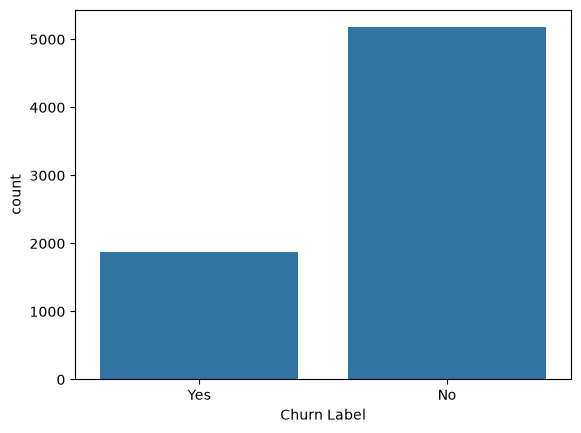

In [15]:
# Overall churn distribution 
sns.countplot(x='Churn Label',data=df)
plt.show()

**Insight:** Most customers did not churn, while fewer customers churned (about 26.5%).

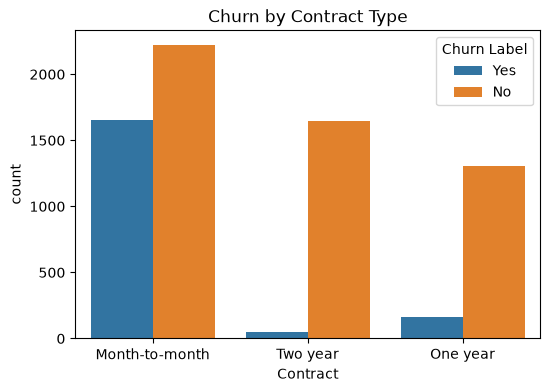

In [17]:
# Contract vs churn Label
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Contract',hue='Churn Label')
plt.title('Churn by Contract Type')
plt.show()

**Insight:** Month-to-month contracts have far more churned customers than one-year and two-year contracts.

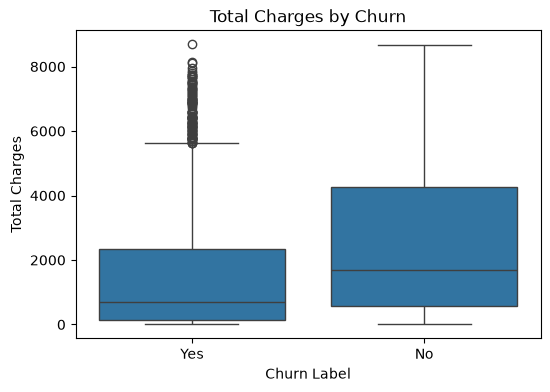

In [19]:
# Total charges vs churn Label
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn Label', y='Total Charges')
plt.title('Total Charges by Churn')
plt.show()

**Insight:** Churned customers have a lower median Total Charges than retained customers, since they leave early. A few long-tenure, high-spending churned customers appear as outliers.

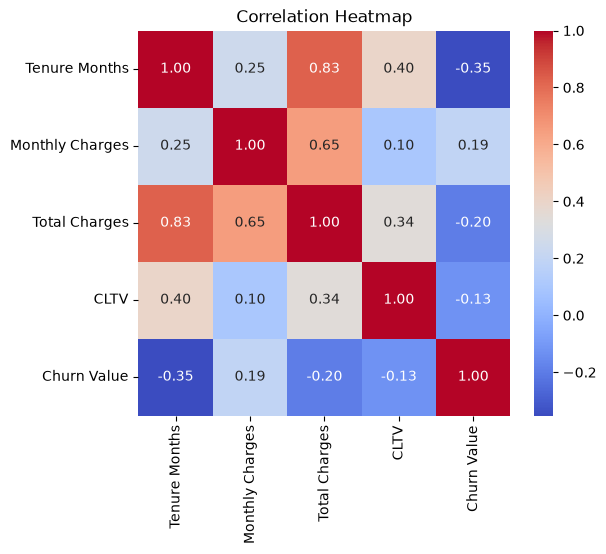

In [21]:
# Numeric features correlation Heatmap
numeric_df = df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Value']]
plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


**Insight:** Tenure Months has the strongest correlation with churn (-0.35), meaning customers with longer tenure churn less. Monthly Charges is weakly positive (0.19).

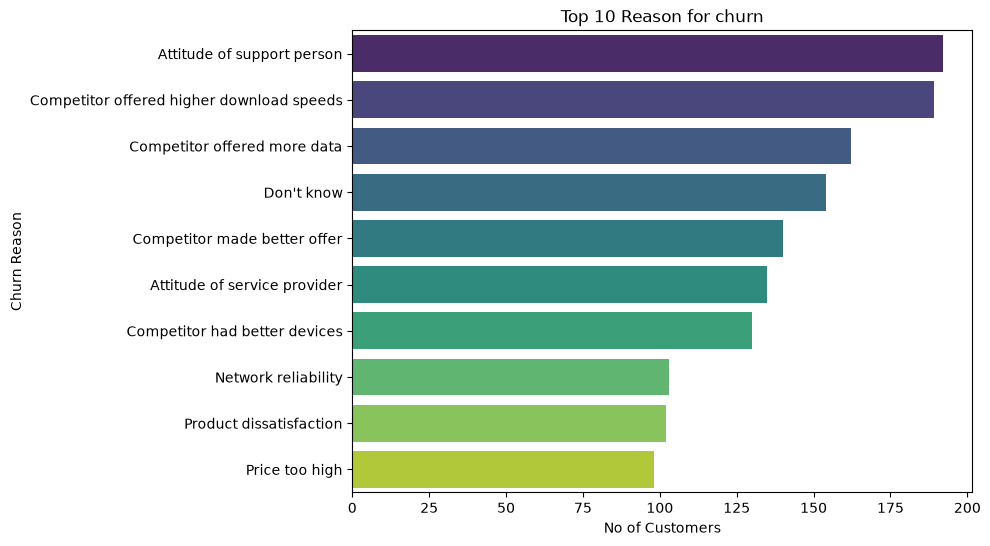

In [23]:
# Churned Customer :Top Reasons
top_reasons=df[df['Churn Value']==1]['Churn Reason'].value_counts().head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=top_reasons.values,y=top_reasons.index,hue=top_reasons.index,legend=False,palette='viridis')
plt.xlabel('No of Customers')
plt.title('Top 10 Reason for churn')
plt.show()

**Insight:** The most common churn reason is the attitude of support staff, followed by competitors offering higher download speeds. Competitor-related reasons (speed, data, offers, devices) together account for a large share of churn.

## 4. Export Cleaned Data

In [26]:
df.to_excel("../data/Telco_customer_churn_cleaned.xlsx", index=False)